# Phase 2 - Model 3: Transformer

**Architecture**: Learnable Positional Encoding + TransformerEncoder (4 layers, 8 heads) + Global Average Pooling  
**Input**: Z (batch, 30, 64) — shared latent space from Feature Aligner  
**Output**: 5-class probabilities (Benign, BruteForce, DDoS, DoS, Infiltration)

In [1]:
import sys, os
import numpy as np
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from feature_alignment import (
    prepare_combined_dataset, FeatureAligner, create_dataloaders,
    DEVICE, LATENT_DIM, WINDOW_SIZE, NUM_CLASSES, UNIFIED_CLASSES
)

print(f"Device: {DEVICE}")


Device: cuda


## 1. Load & Prepare Data

In [2]:
# Load combined dataset
data = prepare_combined_dataset()

uq_windows = data['uq']['windows']
uq_labels = data['uq']['labels']
cic_windows = data['cic']['windows']
cic_labels = data['cic']['labels']
uq_n_feat = data['uq']['n_features']
cic_n_feat = data['cic']['n_features']

# Split data
def split_data(windows, labels, test_size=0.15, val_size=0.15, seed=42):
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        windows, labels, test_size=test_size, random_state=seed, stratify=labels)
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_ratio, random_state=seed, stratify=y_trainval)
    return X_train, X_val, X_test, y_train, y_val, y_test

uq_train, uq_val, uq_test, uq_y_train, uq_y_val, uq_y_test = split_data(uq_windows, uq_labels)
cic_train, cic_val, cic_test, cic_y_train, cic_y_val, cic_y_test = split_data(cic_windows, cic_labels)

print(f"UQ  — Train: {len(uq_train)}, Val: {len(uq_val)}, Test: {len(uq_test)}")
print(f"CIC — Train: {len(cic_train)}, Val: {len(cic_val)}, Test: {len(cic_test)}")


[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
[CIC] Loaded 237618 flows, 78 features
[CIC] Label distribution:
Label
Benign          100000
DoS              71588
DDoS             50000
BruteForce       15994
Infiltration        36
[CIC] Created 101615 windows of shape (101615, 30, 78)
[CIC] Feature dim: 78, Latent target: 64

=== Combined Dataset ===
UQ: 186005 windows, 47 features
CIC: 101615 windows, 78 features
Total: 287620 windows
UQ  — Train: 130203, Val: 27901, Test: 27901
CIC — Train: 71129, Val: 15243, Test: 15243


## 2. Define Transformer Model

**Architecture:**
- Learnable Positional Encoding (30 positions, 64-dim)
- TransformerEncoder: 4 layers, d_model=64, nhead=8, dim_feedforward=256
- Global Average Pooling over time dimension
- FC: 64→5 (softmax)

In [3]:
class LearnablePositionalEncoding(nn.Module):
    """Learnable positional encoding for time-series Transformer."""

    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    """
    Transformer Encoder for time-series classification.
    """

    def __init__(self, d_model=LATENT_DIM, nhead=8, num_layers=4,
                 dim_feedforward=256, dropout=0.1, num_classes=NUM_CLASSES):
        super().__init__()

        self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=WINDOW_SIZE)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.layer_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, z):
        """
        Args:
            z: (batch, time_steps, d_model) — from FeatureAligner
        Returns:
            logits: (batch, num_classes)
        """
        x = self.pos_encoder(z)                     # (B, 30, 64)
        x = self.transformer_encoder(x)             # (B, 30, 64)
        x = self.layer_norm(x)

        # Global Average Pooling over time
        x = x.mean(dim=1)                           # (B, 64)

        logits = self.classifier(x)                  # (B, 5)
        return logits


class TransformerWithAligner(nn.Module):
    """End-to-end model: FeatureAligner + Transformer."""

    def __init__(self, uq_input_dim, cic_input_dim):
        super().__init__()
        self.aligner = FeatureAligner(uq_input_dim, cic_input_dim)
        self.transformer = TransformerClassifier()

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)
        logits = self.transformer(z)
        return logits

    def predict_proba(self, x, dataset_type='uq'):
        logits = self.forward(x, dataset_type)
        return torch.softmax(logits, dim=1)


model = TransformerWithAligner(uq_n_feat, cic_n_feat).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Transformer Model: {total_params:,} params ({trainable_params:,} trainable)")
print(model)


Transformer Model: 235,845 params (235,845 trainable)
TransformerWithAligner(
  (aligner): FeatureAligner(
    (uq_extractor): UQFeatureExtractor(
      (net): Sequential(
        (0): Linear(in_features=47, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
      )
    )
    (cic_extractor): CICFeatureExtractor(
      (net): Sequential(
        (0): Linear(in_features=78, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine

## 3. Training

In [4]:
def train_epoch(model, uq_loader, cic_loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    uq_iter, cic_iter = iter(uq_loader), iter(cic_loader)
    while True:
        done = True
        for it_name in ['uq', 'cic']:
            it = uq_iter if it_name == 'uq' else cic_iter
            if it is None:
                continue
            try:
                x, y, _ = next(it)
                done = False
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                logits = model(x, it_name)
                loss = criterion(logits, y)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item() * len(y)
                total_correct += (logits.argmax(1) == y).sum().item()
                total_samples += len(y)
            except StopIteration:
                if it_name == 'uq':
                    uq_iter = None
                else:
                    cic_iter = None
        if done or (uq_iter is None and cic_iter is None):
            break
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, uq_loader, cic_loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    for loader, dtype in [(uq_loader, 'uq'), (cic_loader, 'cic')]:
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, dtype)
            loss = criterion(logits, y)
            total_loss += loss.item() * len(y)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_samples += len(y)
    return total_loss / total_samples, total_correct / total_samples


In [5]:
# Hyperparameters
EPOCHS = 50
BATCH_SIZE = 256
LR = 5e-4
PATIENCE = 7

# DataLoaders
uq_train_loader = create_dataloaders(uq_train, uq_y_train, 'uq', BATCH_SIZE, shuffle=True)
uq_val_loader = create_dataloaders(uq_val, uq_y_val, 'uq', BATCH_SIZE, shuffle=False)
cic_train_loader = create_dataloaders(cic_train, cic_y_train, 'cic', BATCH_SIZE, shuffle=True)
cic_val_loader = create_dataloaders(cic_val, cic_y_val, 'cic', BATCH_SIZE, shuffle=False)

# Class weights
all_train_labels = np.concatenate([uq_y_train, cic_y_train])
class_counts = np.bincount(all_train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights).to(DEVICE))

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Training Transformer ===\n")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, uq_train_loader, cic_train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, uq_val_loader, cic_val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        os.makedirs('../Project/Model/Model_2017', exist_ok=True)
        torch.save(model.state_dict(), '../Project/Model/Model_2017/transformer_best.pth')
        print(f"  → Saved best model (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest validation loss: {best_val_loss:.4f}")


=== Training Transformer ===

Epoch   1/50 | Train Loss: 0.2052 Acc: 0.8999 | Val Loss: 0.1205 Acc: 0.9210 | LR: 5.00e-04
  → Saved best model (val_loss: 0.1205)
Epoch   2/50 | Train Loss: 0.1158 Acc: 0.9414 | Val Loss: 0.1105 Acc: 0.9392 | LR: 4.98e-04
  → Saved best model (val_loss: 0.1105)
Epoch   3/50 | Train Loss: 0.1047 Acc: 0.9453 | Val Loss: 0.0965 Acc: 0.9588 | LR: 4.96e-04
  → Saved best model (val_loss: 0.0965)
Epoch   4/50 | Train Loss: 0.0980 Acc: 0.9485 | Val Loss: 0.0999 Acc: 0.9434 | LR: 4.92e-04
Epoch   5/50 | Train Loss: 0.0939 Acc: 0.9487 | Val Loss: 0.0890 Acc: 0.9387 | LR: 4.88e-04
  → Saved best model (val_loss: 0.0890)
Epoch   6/50 | Train Loss: 0.0898 Acc: 0.9504 | Val Loss: 0.0860 Acc: 0.9511 | LR: 4.82e-04
  → Saved best model (val_loss: 0.0860)
Epoch   7/50 | Train Loss: 0.0868 Acc: 0.9516 | Val Loss: 0.0860 Acc: 0.9551 | LR: 4.76e-04
  → Saved best model (val_loss: 0.0860)
Epoch   8/50 | Train Loss: 0.0838 Acc: 0.9518 | Val Loss: 0.0802 Acc: 0.9532 | LR: 4.6

## 4. Evaluation

=== Transformer Test Results ===

              precision    recall  f1-score   support

      Benign     0.9897    0.9535    0.9712     24191
  BruteForce     0.9642    0.9930    0.9784      4995
        DDoS     0.9959    0.9995    0.9977      5802
         DoS     0.9889    0.9572    0.9728      3711
Infiltration     0.7967    0.9462    0.8651      4445

    accuracy                         0.9638     43144
   macro avg     0.9471    0.9699    0.9570     43144
weighted avg     0.9676    0.9638    0.9648     43144



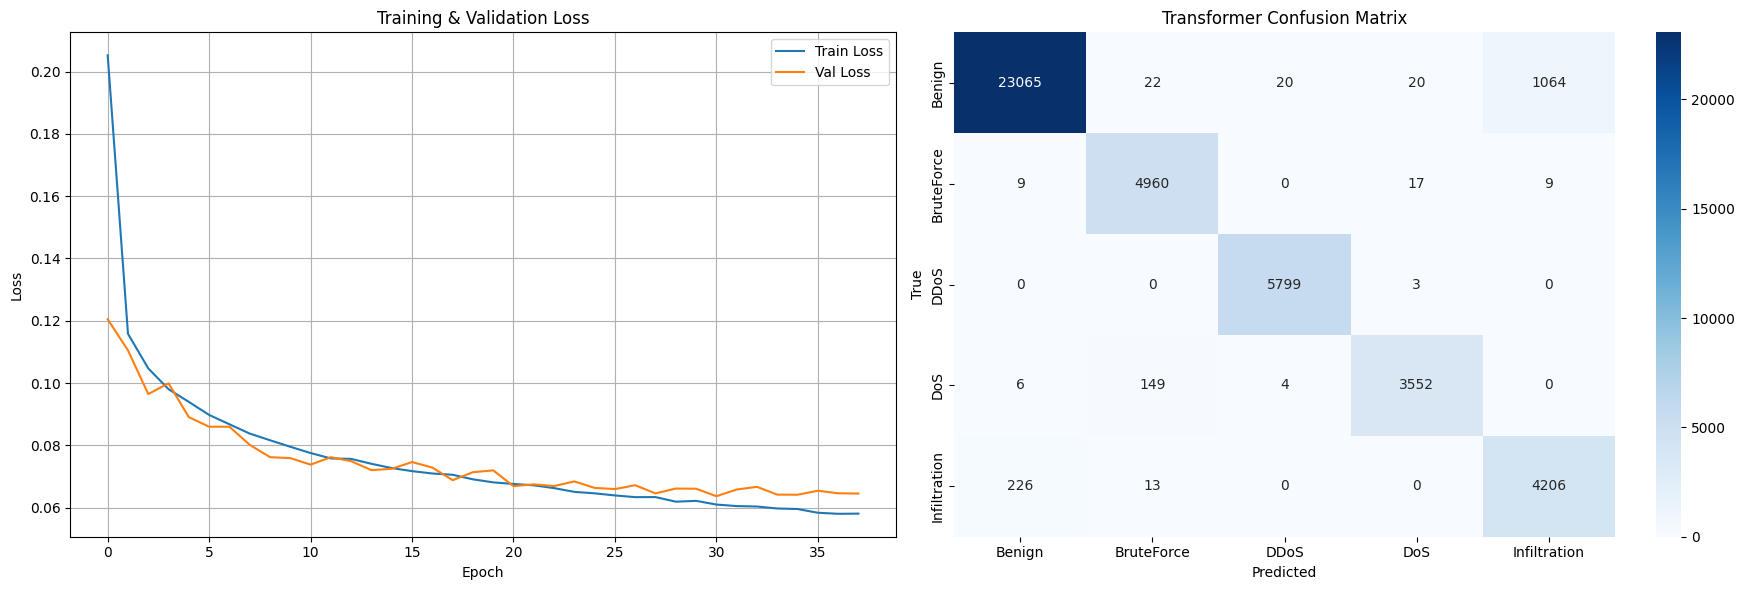

Results saved.


: 

In [ ]:
# Load best model
model.load_state_dict(torch.load('../Project/Model/Model_2017/transformer_best.pth', weights_only=True))
model.eval()

uq_test_loader = create_dataloaders(uq_test, uq_y_test, 'uq', BATCH_SIZE, shuffle=False)
cic_test_loader = create_dataloaders(cic_test, cic_y_test, 'cic', BATCH_SIZE, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for loader, dtype in [(uq_test_loader, 'uq'), (cic_test_loader, 'cic')]:
        for x, y, _ in loader:
            x = x.to(DEVICE)
            logits = model(x, dtype)
            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== Transformer Test Results ===\n")
print(classification_report(all_labels, all_preds, target_names=UNIFIED_CLASSES, digits=4))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(True)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIFIED_CLASSES, yticklabels=UNIFIED_CLASSES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Transformer Confusion Matrix')

plt.tight_layout()
plt.savefig('../Project/Model/Model_2017/transformer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved.")
